# Modelos ARMA e ARIMA para Análise de Séries Temporais


## Introdução aos Modelos de Séries Temporais

Séries temporais são sequências de dados indexadas no tempo. A análise de séries temporais é crucial em diversas áreas, como finanças, economia, meteorologia e engenharia, para entender padrões passados e prever comportamentos futuros.

Modelos de séries temporais são ferramentas estatísticas que capturam a estrutura de dependência temporal nos dados. Os modelos AR (AutoRegressivo), MA (Médias Móveis), ARMA (AutoRegressivo de Médias Móveis) e ARIMA (AutoRegressivo Integrado de Médias Móveis) são alguns dos mais fundamentais e amplamente utilizados.

### Modelo AutoRegressivo (AR)

Um modelo AR($p$) prevê o valor futuro de uma série temporal com base em seus próprios valores passados (lags). A ordem $p$ indica o número de observações passadas incluídas no modelo. A equação para um modelo AR($p$) é:

$$X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p} + \epsilon_t$$

Onde:
- $X_t$ é o valor da série no tempo $t$.
- $c$ é uma constante.
- $\phi_i$ são os coeficientes autorregressivos para os lags $i$.
- $\epsilon_t$ é o termo de erro (ruído branco), assumido como independente e identicamente distribuído (i.i.d.) com média zero e variância constante.

### Modelo de Médias Móveis (MA)

Um modelo MA($q$) prevê o valor futuro de uma série temporal com base em uma combinação linear dos termos de erro passados (ruído branco). A ordem $q$ indica o número de termos de erro passados incluídos no modelo. A equação para um modelo MA($q$) é:

$$X_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q}$$

Onde:
- $X_t$ é o valor da série no tempo $t$.
- $\mu$ é a média da série.
- $\epsilon_t$ é o termo de erro (ruído branco) no tempo $t$.
- $\theta_i$ são os coeficientes de médias móveis para os lags $i$.

### Modelo AutoRegressivo de Médias Móveis (ARMA)

Um modelo ARMA($p, q$) combina os componentes AR e MA. Ele é apropriado para séries temporais estacionárias, onde a média e a variância são constantes ao longo do tempo. A equação para um modelo ARMA($p, q$) é:

$$X_t = c + \phi_1 X_{t-1} + \dots + \phi_p X_{t-p} + \epsilon_t + \theta_1 \epsilon_{t-1} + \dots + \theta_q \epsilon_{t-q}$$

Onde $p$ é a ordem da parte AR e $q$ é a ordem da parte MA.

### Modelo AutoRegressivo Integrado de Médias Móveis (ARIMA)

O modelo ARIMA($p, d, q$) é uma extensão do modelo ARMA que lida com séries temporais não estacionárias. A parte 'I' (Integrado) refere-se à diferenciação, que é o processo de subtrair o valor de uma observação anterior do valor atual. Isso é feito para tornar a série estacionária. A ordem $d$ indica o número de vezes que a série precisa ser diferenciada. Uma vez que a série se torna estacionária após $d$ diferenciações, um modelo ARMA($p, q$) é ajustado aos dados diferenciados.

A série diferenciada $Y_t$ é definida como:

$$Y_t = \nabla^d X_t$$

Onde $\nabla$ é o operador de diferença. Por exemplo, para $d=1$, $Y_t = X_t - X_{t-1}$.

O modelo ARIMA($p, d, q$) é, portanto, um modelo ARMA($p, q$) aplicado à série $d$-diferenciada.

### Adequação de Modelos

A adequação de um modelo de série temporal envolve as seguintes etapas:
1.  **Visualização dos Dados:** Inspecionar a série temporal para identificar tendências, sazonalidade e estacionaridade.
2.  **Teste de Estacionaridade:** Utilizar testes estatísticos (KPSS, ADF) para verificar se a série é estacionária.
3.  **Diferenciação (se necessário):** Aplicar diferenciações para tornar a série estacionária, determinando a ordem $d$ para o ARIMA.
4.  **Análise das Funções de Autocorrelação (ACF) e Autocorrelação Parcial (PACF):** Essas funções ajudam a identificar as ordens $p$ e $q$ dos componentes AR e MA:
    -   **AR($p$):** A PACF corta em $p$ lags, enquanto a ACF decai exponencialmente.
    -   **MA($q$):** A ACF corta em $q$ lags, enquanto a PACF decai exponencialmente.
    -   **ARMA($p, q$):** Tanto a ACF quanto a PACF decaem exponencialmente.
5.  **Ajuste do Modelo:** Ajustar o modelo ARIMA($p, d, q$) com as ordens identificadas.
6.  **Análise dos Resíduos:** Verificar se os resíduos do modelo são ruído branco (independentes, identicamente distribuídos, com média zero e variância constante, e normalmente distribuídos). Isso é crucial para validar o modelo.
7.  **Comparação de Modelos:** Utilizar critérios de informação (AIC, BIC) para comparar diferentes modelos e selecionar o melhor.


In [1]:
# Instalação da biblioteca pmdarima (se necessário)
# !pip install pmdarima


In [2]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess # Para simular séries ARMA
from pmdarima import auto_arima
from pmdarima.arima.utils import ndiffs
from scipy.stats import shapiro
import warnings
warnings.filterwarnings('ignore')


### Função Auxiliar para Plotar ACF e PACF

Esta função centraliza a visualização da série temporal, sua Autocorrelação (ACF) e Autocorrelação Parcial (PACF), facilitando a análise visual da dependência temporal e a identificação das ordens de modelos AR e MA.


In [3]:
def plot_acf_pacf(series, lags=20, title=''):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(series)
    axes[0].set_title(f'Série Temporal - {title}')
    plot_acf(series, lags=lags, ax=axes[1], title=f'Função de Autocorrelação (ACF) - {title}')
    plot_pacf(series, lags=lags, ax=axes[2], title=f'Função de Autocorrelação Parcial (PACF) - {title}')
    plt.tight_layout()
    plt.show()

## Simulação de um Modelo ARIMA

Vamos simular uma série temporal que segue um processo ARIMA(1,1,1). Isso significa que a série original não é estacionária e requer uma diferenciação para se tornar estacionária. Após a diferenciação, a série resultante se comporta como um processo ARMA(1,1).

Um processo ARIMA($p, d, q$) é construído a partir de um processo ARMA($p, q$) aplicado à série diferenciada $d$ vezes. Para simular um ARIMA(1,1,1), simulamos um ARMA(1,1) e, em seguida, aplicamos a soma cumulativa para reverter a diferenciação, tornando a série não estacionária.


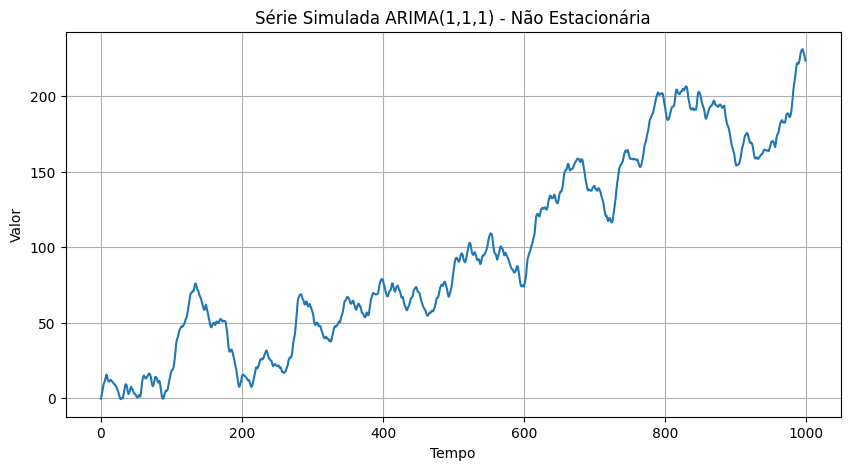

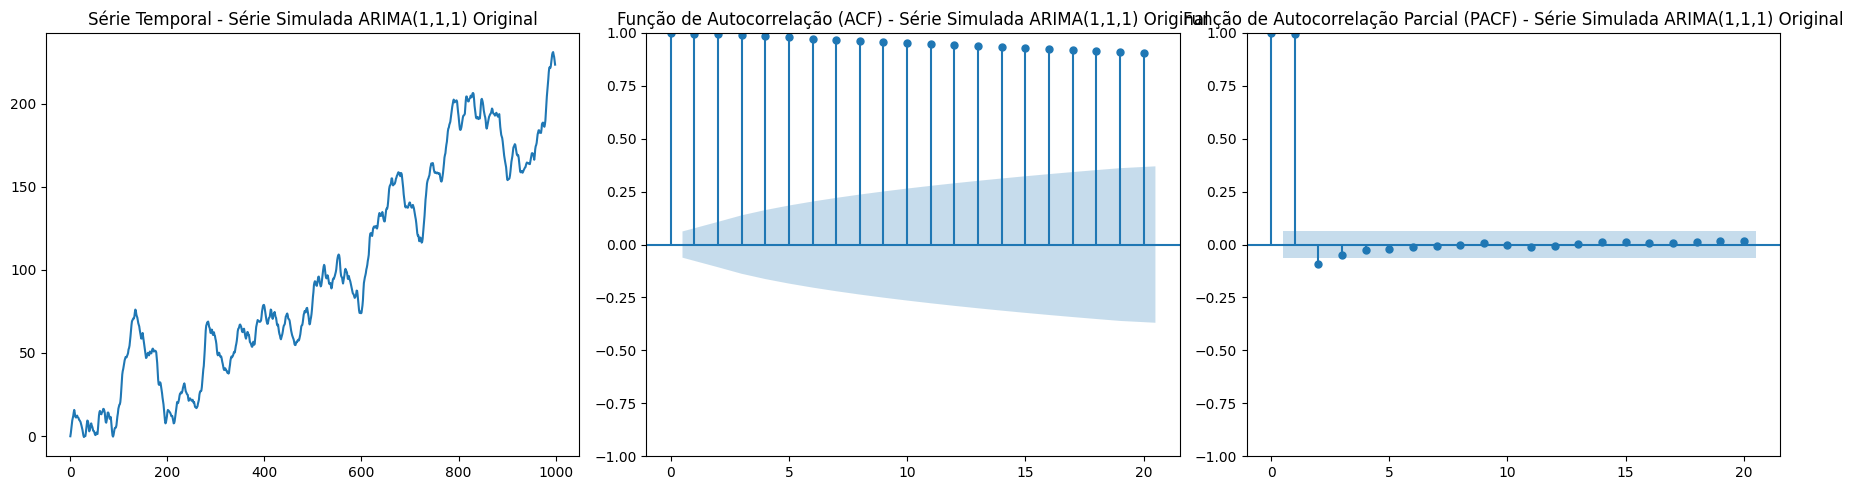

In [4]:
np.random.seed(99)
# Parâmetros AR e MA para o processo ARMA(1,1) subjacente
# Note: os parâmetros AR são dados como [1, -phi1, -phi2, ...] em ArmaProcess
# e os parâmetros MA são dados como [1, theta1, theta2, ...] em ArmaProcess
ar_params = np.array([0.6]) # phi_1 = 0.6
ma_params = np.array([0.5]) # theta_1 = 0.5

# Prepend 1 to the parameters for ArmaProcess
ar = np.r_[1, -ar_params]
ma = np.r_[1, ma_params]

arma_process = ArmaProcess(ar, ma)
n_samples = 1000
stationary_series = arma_process.generate_sample(nsample=n_samples)

# Converter o processo ARMA(1,1) em ARIMA(1,1,1) através de diferenciação (acumulação)
x = np.cumsum(stationary_series) 

plt.figure(figsize=(10, 5))
plt.plot(x)
plt.title('Série Simulada ARIMA(1,1,1) - Não Estacionária')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

plot_acf_pacf(x, title='Série Simulada ARIMA(1,1,1) Original')


## Teste de Estacionaridade

A estacionaridade é uma propriedade fundamental em séries temporais para a aplicação de muitos modelos, incluindo ARMA. Uma série é estacionária se suas propriedades estatísticas (média, variância e autocovariância) são constantes ao longo do tempo. Séries não estacionárias podem apresentar tendências, sazonalidade ou mudanças na variância.

### Teste KPSS

O **Teste Kwiatkowski-Phillips-Schmidt-Shin (KPSS)** verifica se uma série temporal é estacionária ao redor de uma média ou tendência constante. É um teste de estacionaridade de nível ou de tendência, ao contrário do ADF que é um teste de raiz unitária.

-   **Hipótese Nula (H0)**: A série é estacionária (não possui raiz unitária).
-   **Hipótese Alternativa (Ha)**: A série não é estacionária (possui raiz unitária, ou seja, é integrada).

Um p-valor abaixo de um nível de significância (e.g., 0.05) leva à rejeição da hipótese nula, indicando que a série não é estacionária.


In [5]:
print('Realizando Teste KPSS na Série Simulada ARIMA(1,1,1) Original:')
kpss_stat, p_value, lags, critical_values = kpss(x, regression='c')
print(f'Estatística do teste: {kpss_stat:.4f}')
print(f'p-valor: {p_value:.4f}')
print('Valores Críticos:')
for key, value in critical_values.items():
    print(f'{key}: {value:.4f}')
print('Resultado:')
if p_value > 0.05:
    print("Falha ao rejeitar a hipótese nula: A série é estacionária.")
else:
    print("Rejeitamos a hipótese nula: A série não é estacionária (possui uma raiz unitária).")


Realizando Teste KPSS na Série Simulada ARIMA(1,1,1) Original:
Estatística do teste: 4.7594
p-valor: 0.0100
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Rejeitamos a hipótese nula: A série não é estacionária (possui uma raiz unitária).


### Teste ADF (Augmented Dickey-Fuller)

O **Teste ADF** é outro teste comum para verificar a estacionaridade. Ele testa a presença de uma raiz unitária em uma série temporal, que é uma característica de séries não estacionárias.

-   **Hipótese Nula (H0)**: A série não é estacionária (possui uma raiz unitária).
-   **Hipótese Alternativa (Ha)**: A série é estacionária (não possui raiz unitária).

Um p-valor abaixo de um nível de significância (e.g., 0.05) leva à rejeição da hipótese nula, indicando que a série é estacionária.


In [6]:
print('\nRealizando Teste ADF na Série Simulada ARIMA(1,1,1) Original:')
adf_result = adfuller(x)
print(f'Estatística do teste: {adf_result[0]:.4f}')
print(f'p-valor: {adf_result[1]:.4f}')
print('Valores Críticos:')
for key, value in adf_result[4].items():
    print(f'{key}: {value:.4f}')
print('Resultado:')
if adf_result[1] <= 0.05:
    print("Rejeitamos a hipótese nula: A série é estacionária.")
else:
    print("Falha ao rejeitar a hipótese nula: A série não é estacionária.")



Realizando Teste ADF na Série Simulada ARIMA(1,1,1) Original:
Estatística do teste: -0.7054
p-valor: 0.8453
Valores Críticos:
1%: -3.4369
5%: -2.8645
10%: -2.5683
Resultado:
Falha ao rejeitar a hipótese nula: A série não é estacionária.


Como ambos os testes indicam que a série é não estacionária, devemos transformá-la em uma série estacionária através da diferenciação.

### Determinação do Número de Diferenciações Necessárias (d)

A função `ndiffs` do `pmdarima` é uma ferramenta útil para estimar a ordem de diferenciação ($d$) necessária para tornar uma série temporal estacionária. Ela pode usar diferentes testes estatísticos, como KPSS ou ADF. Para nossa série simulada, esperamos que `d=1`.


In [7]:
# Determinação do número de diferenciações necessárias usando o teste KPSS (padrão de ndiffs)
d = ndiffs(x, test='kpss', max_d=5)
print(f'Número de diferenciações necessárias (d): {d}')

Número de diferenciações necessárias (d): 1


### Aplicando as Diferenciações

Aplicamos a diferenciação de primeira ordem à série original $X_t$ para obter a série estacionária $W_t$. Esperamos que $W_t$ se pareça com a série ARMA(1,1) que simulamos inicialmente.


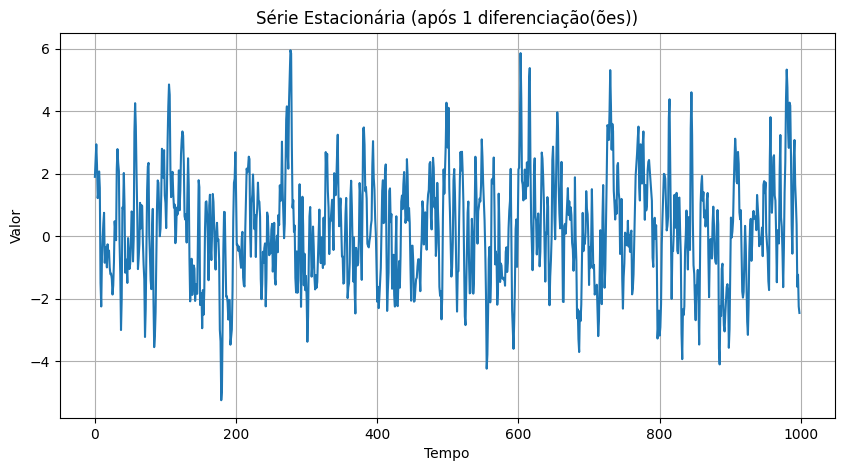

In [8]:
w = np.diff(x, n=d)
plt.figure(figsize=(10, 5))
plt.plot(w)
plt.title(f'Série Estacionária (após {d} diferenciação(ões))')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True)
plt.show()


### Reavaliando a Estacionaridade da Série Diferenciada

É uma boa prática reconfirmar a estacionaridade após a diferenciação.


In [9]:
print('Realizando Teste KPSS na Série Diferenciada:')
kpss_stat_diff, p_value_diff, lags_diff, critical_values_diff = kpss(w, regression='c')
print(f'Estatística do teste: {kpss_stat_diff:.4f}')
print(f'p-valor: {p_value_diff:.4f}')
print('Valores Críticos:')
for key, value in critical_values_diff.items():
    print(f'{key}: {value:.4f}')
print('Resultado:')
if p_value_diff > 0.05:
    print("Falha ao rejeitar a hipótese nula: A série diferenciada é estacionária.")
else:
    print("Rejeitamos a hipótese nula: A série diferenciada não é estacionária.")


Realizando Teste KPSS na Série Diferenciada:
Estatística do teste: 0.0450
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Falha ao rejeitar a hipótese nula: A série diferenciada é estacionária.


In [10]:
print('\nRealizando Teste ADF na Série Diferenciada:')
adf_result_diff = adfuller(w)
print(f'Estatística do teste: {adf_result_diff[0]:.4f}')
print(f'p-valor: {adf_result_diff[1]:.4f}')
print('Valores Críticos:')
for key, value in adf_result_diff[4].items():
    print(f'{key}: {value:.4f}')
print('Resultado:')
if adf_result_diff[1] <= 0.05:
    print("Rejeitamos a hipótese nula: A série diferenciada é estacionária.")
else:
    print("Falha ao rejeitar a hipótese nula: A série diferenciada não é estacionária.")



Realizando Teste ADF na Série Diferenciada:
Estatística do teste: -9.2992
p-valor: 0.0000
Valores Críticos:
1%: -3.4369
5%: -2.8645
10%: -2.5683
Resultado:
Rejeitamos a hipótese nula: A série diferenciada é estacionária.


## Análise da Série Estacionária (diferenciada)

Agora que a série é estacionária, podemos analisar suas Funções de Autocorrelação (ACF) e Autocorrelação Parcial (PACF) para determinar as ordens $p$ e $q$ para um modelo ARMA (que será a base do nosso ARIMA).


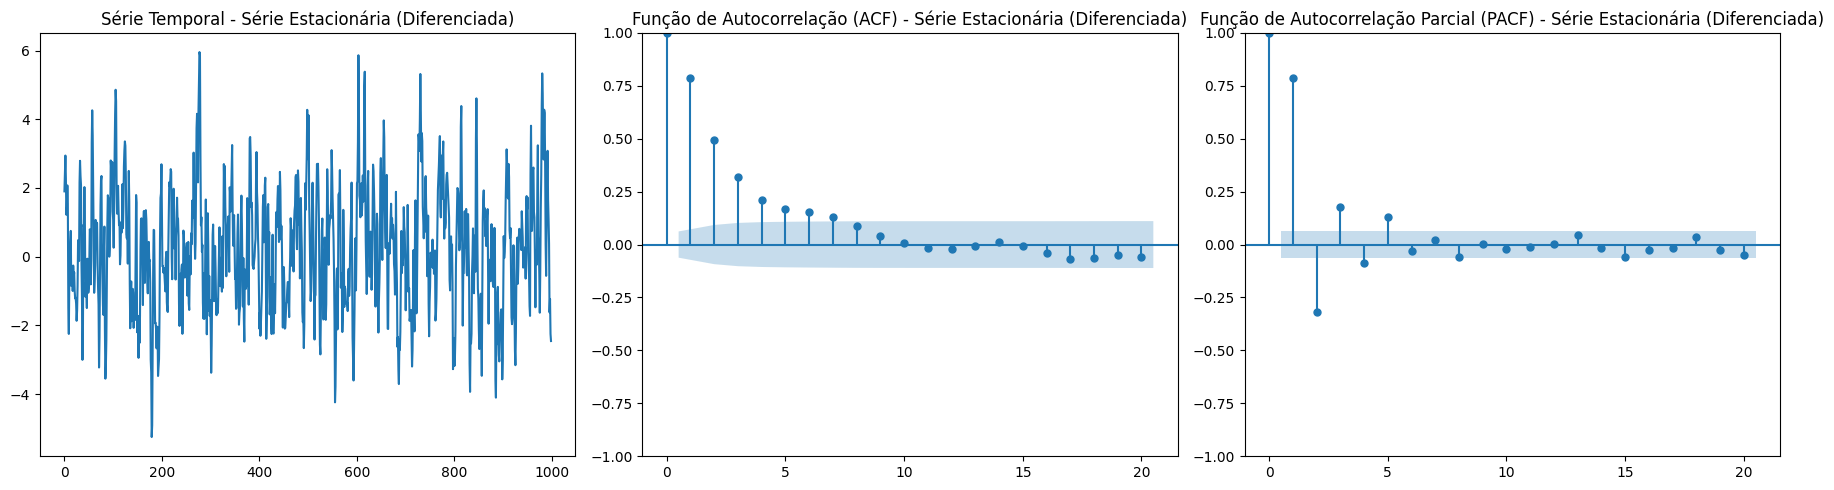

In [11]:
plot_acf_pacf(w, title='Série Estacionária (Diferenciada)')


**Análise das ACF e PACF para $W_t$ (série diferenciada):**

-   A **PACF** mostra um pico significativo no lag 1 e, em seguida, valores não significativos ou que decaem rapidamente. Isso sugere um componente AR(1).
-   A **ACF** também mostra um pico significativo no lag 1 e, em seguida, valores que decaem rapidamente. Isso sugere um componente MA(1).

A combinação desses padrões (ambas as funções cortando ou decaindo rapidamente após o primeiro lag) é característica de um processo ARMA(1,1). Como nossa série original foi diferenciada uma vez ($d=1$), isso sugere que um modelo ARIMA(1,1,1) é apropriado para a série original $X_t$.


## Ajustando Modelos AR, MA e ARMA à Série Estacionária (`w`)


### Ajustando um Modelo ARMA(1,1)

Com base na análise das ACF/PACF da série diferenciada ($w$), a escolha mais natural é um modelo ARMA(1,1). Em termos de ARIMA, isso se traduz em um ARIMA(1,1,1) para a série original ($x$).

Vamos ajustar este modelo à série $w$ e analisar seus resíduos.


In [12]:
print('Ajustando o Modelo ARMA(1,1) à série diferenciada (w)...')
ARMA_model = ARIMA(w, order=(1, 0, 1)).fit()
E_ARMA = ARMA_model.resid
print('Modelo ARMA(1,1) ajustado com sucesso.')


Ajustando o Modelo ARMA(1,1) à série diferenciada (w)...
Modelo ARMA(1,1) ajustado com sucesso.


### Análise Gráfica dos Resíduos do Modelo ARMA(1,1)

Os resíduos de um bom modelo de série temporal devem se assemelhar a ruído branco: não devem apresentar autocorrelação significativa e devem ser normalmente distribuídos. As plotagens ACF/PACF e o QQ-plot nos ajudarão a verificar isso.


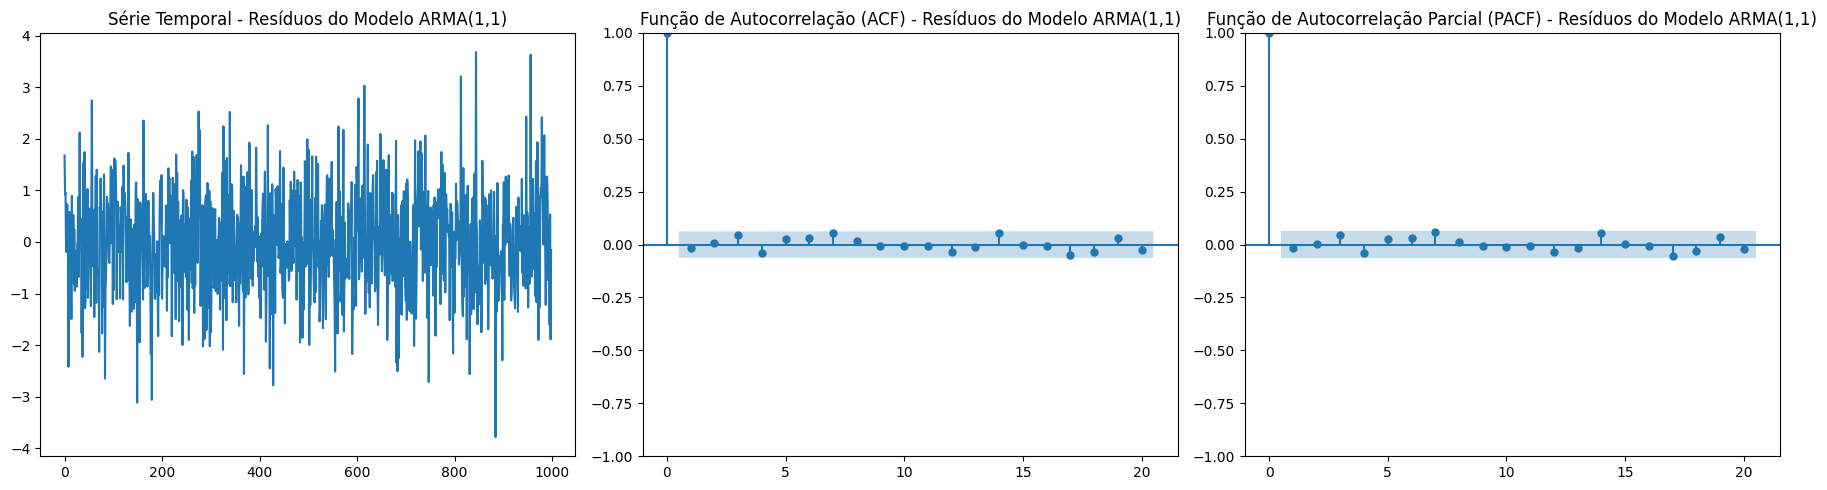

<Figure size 600x400 with 0 Axes>

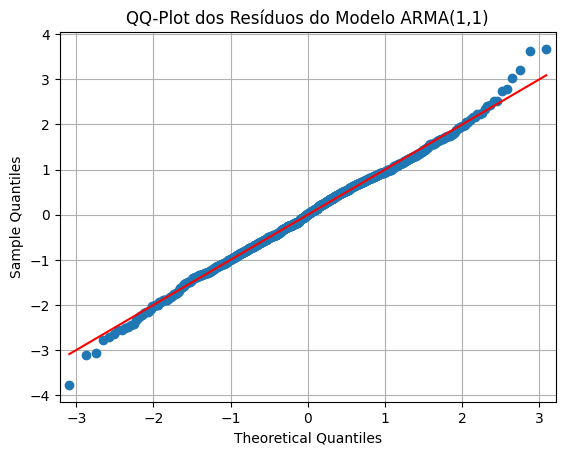

In [13]:
plot_acf_pacf(E_ARMA, title='Resíduos do Modelo ARMA(1,1)')
plt.figure(figsize=(6, 4))
sm.qqplot(E_ARMA, line='s', fit=True)
plt.title('QQ-Plot dos Resíduos do Modelo ARMA(1,1)')
plt.grid(True)
plt.show()


### Testes Estatísticos para Validar o Modelo ARMA(1,1)

Para formalizar a avaliação dos resíduos, realizaremos os seguintes testes estatísticos:

#### Teste de Estacionaridade - KPSS para Resíduos

Verificamos se os resíduos são estacionários, o que é um pré-requisito para ruído branco. Espera-se que os resíduos de um modelo bem ajustado sejam estacionários.


In [14]:
print('Teste KPSS para Resíduos do Modelo ARMA(1,1):')
kpss_stat, p_value, lags, critical_values = kpss(E_ARMA, regression='c')
print(f'Estatística do teste: {kpss_stat:.4f}')
print(f'p-valor: {p_value:.4f}')
print('Valores Críticos:')
for key, value in critical_values.items():
    print(f'{key}: {value:.4f}')
print('Resultado:')
if p_value > 0.05:
    print("Falha ao rejeitar a hipótese nula: Os resíduos são estacionários.")
else:
    print("Rejeitamos a hipótese nula: Os resíduos não são estacionários.")


Teste KPSS para Resíduos do Modelo ARMA(1,1):
Estatística do teste: 0.0401
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Falha ao rejeitar a hipótese nula: Os resíduos são estacionários.


#### Teste de Independência - Ljung-Box

O **Teste de Ljung-Box** verifica se as autocorrelações dos resíduos são significativamente diferentes de zero para vários lags. A hipótese nula é que os resíduos são independentemente distribuídos (ruído branco).

-   **Hipótese Nula (H0)**: As autocorrelações dos resíduos são zero (os resíduos são ruído branco).
-   **Hipótese Alternativa (Ha)**: Pelo menos uma autocorrelação é diferente de zero (os resíduos não são ruído branco).

Um p-valor > 0.05 indica que não há evidências suficientes para rejeitar a hipótese nula, ou seja, os resíduos podem ser considerados ruído branco.


In [15]:
print('Teste de Independência - Ljung-Box para Resíduos do Modelo ARMA(1,1):')
# lags=[20] é um valor comum para verificar a independência. Você pode ajustar este valor.
ljung_box_result = sm.stats.acorr_ljungbox(E_ARMA, lags=[20], return_df=True)
print(ljung_box_result)
if ljung_box_result['lb_pvalue'].iloc[0] > 0.05:
    print("\nFalha ao rejeitar a hipótese nula: Os resíduos são independentes (ruído branco).")
else:
    print("\nRejeitamos a hipótese nula: Os resíduos não são independentes.")


Teste de Independência - Ljung-Box para Resíduos do Modelo ARMA(1,1):
      lb_stat  lb_pvalue
20  19.419923     0.4947

Falha ao rejeitar a hipótese nula: Os resíduos são independentes (ruído branco).


#### Teste de Normalidade - Shapiro-Wilk

O **Teste de Shapiro-Wilk** avalia se uma amostra de dados foi retirada de uma população normalmente distribuída. Embora não seja estritamente necessário para a validade do modelo (o Ljung-Box é mais crítico), a normalidade dos resíduos é uma suposição para a validade dos intervalos de confiança e testes de significância dos parâmetros do modelo.

-   **Hipótese Nula (H0)**: Os dados são normalmente distribuídos.
-   **Hipótese Alternativa (Ha)**: Os dados não são normalmente distribuídos.

Um p-valor > 0.05 sugere que podemos assumir a normalidade.


In [16]:
print('Teste de Normalidade - Shapiro-Wilk para Resíduos do Modelo ARMA(1,1):')
shapiro_stat, shapiro_p_value = shapiro(E_ARMA)
print(f'Estatística do teste: {shapiro_stat:.4f}')
print(f'p-valor: {shapiro_p_value:.4f}')
if shapiro_p_value > 0.05:
    print("Falha ao rejeitar a hipótese nula: Os resíduos são normalmente distribuídos.")
else:
    print("Rejeitamos a hipótese nula: Os resíduos não são normalmente distribuídos.")


Teste de Normalidade - Shapiro-Wilk para Resíduos do Modelo ARMA(1,1):
Estatística do teste: 0.9974
p-valor: 0.1174
Falha ao rejeitar a hipótese nula: Os resíduos são normalmente distribuídos.


## Ajustando um Modelo ARIMA(p,d,q) diretamente na série original (`x`)

Embora tenhamos ajustado um ARMA à série diferenciada, é mais comum na prática ajustar o ARIMA diretamente à série original não estacionária. O `statsmodels.tsa.arima.model.ARIMA` pode lidar com a diferenciação internamente, através do parâmetro `order=(p,d,q)`.


Ajustando o Modelo ARIMA(1,1,1) à série original (x)...
Modelo ARIMA(1,1,1) ajustado com sucesso à série original.


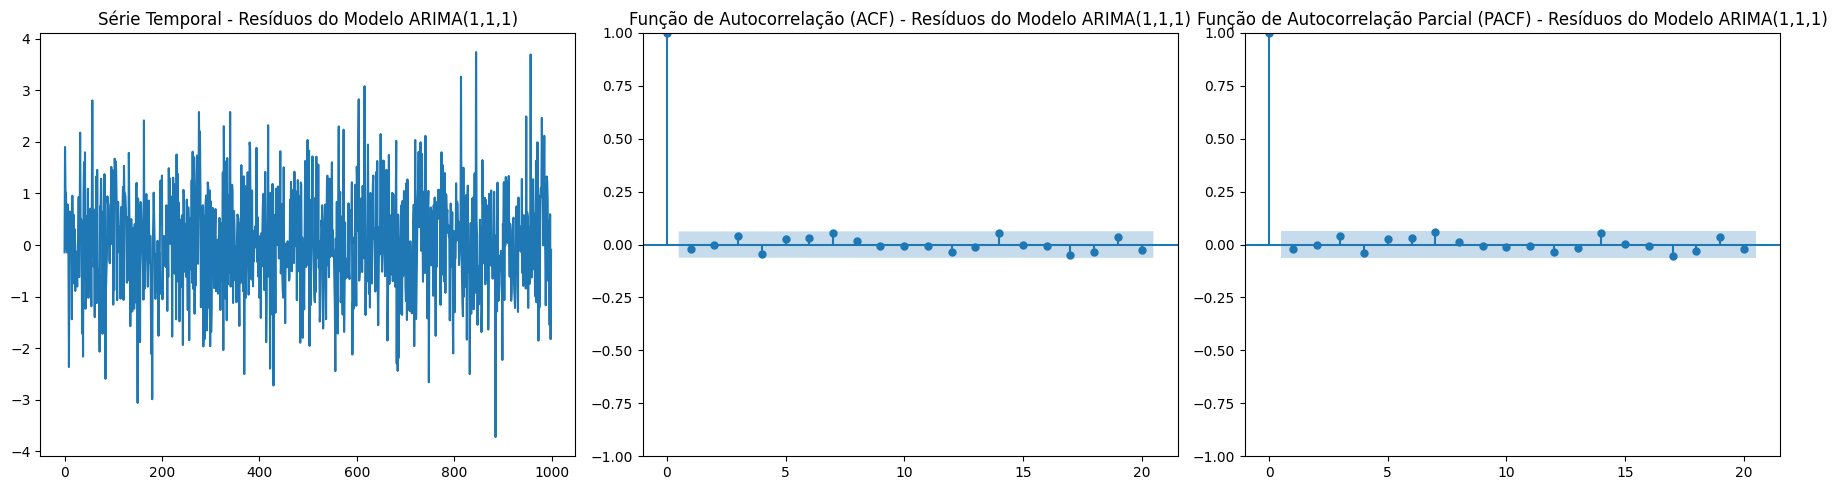

<Figure size 600x400 with 0 Axes>

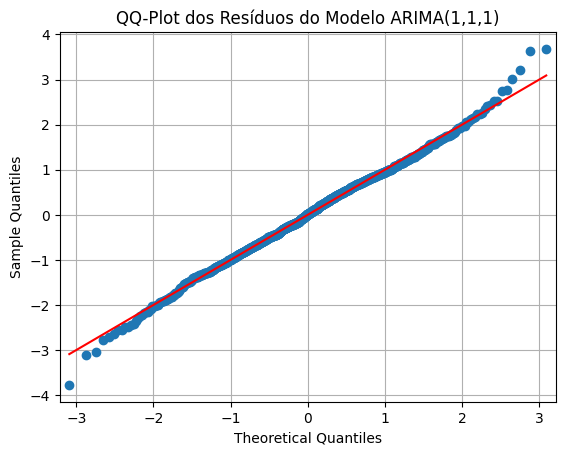


Teste de Independência - Ljung-Box para Resíduos do Modelo ARIMA(1,1,1):
      lb_stat  lb_pvalue
20  19.382346   0.497113

Falha ao rejeitar a hipótese nula: Os resíduos são independentes (ruído branco).


In [17]:
print('Ajustando o Modelo ARIMA(1,1,1) à série original (x)...')
ARIMA_model_direct = ARIMA(x, order=(1, d, 1)).fit()
E_ARIMA_direct = ARIMA_model_direct.resid
print('Modelo ARIMA(1,1,1) ajustado com sucesso à série original.')

plot_acf_pacf(E_ARIMA_direct, title='Resíduos do Modelo ARIMA(1,1,1)')
plt.figure(figsize=(6, 4))
sm.qqplot(E_ARIMA_direct, line='s', fit=True)
plt.title('QQ-Plot dos Resíduos do Modelo ARIMA(1,1,1)')
plt.grid(True)
plt.show()

print('\nTeste de Independência - Ljung-Box para Resíduos do Modelo ARIMA(1,1,1):')
ljung_box_result_direct = sm.stats.acorr_ljungbox(E_ARIMA_direct, lags=[20], return_df=True)
print(ljung_box_result_direct)
if ljung_box_result_direct['lb_pvalue'].iloc[0] > 0.05:
    print("\nFalha ao rejeitar a hipótese nula: Os resíduos são independentes (ruído branco).")
else:
    print("\nRejeitamos a hipótese nula: Os resíduos não são independentes.")


## Comparação de Modelos e Seleção Automática

Após ajustar um ou mais modelos, é importante compará-los para escolher o melhor. Critérios de informação como o **AIC (Akaike Information Criterion)** e **BIC (Bayesian Information Criterion)** são comumente usados. Modelos com valores menores de AIC e BIC são geralmente preferíveis, pois penalizam a complexidade do modelo (maior número de parâmetros) enquanto recompensam o bom ajuste aos dados.

-   **AIC:** Minimiza a perda de informação do modelo. Tende a selecionar modelos mais complexos (maior $p+q$).
-   **BIC:** Penaliza mais fortemente a complexidade do modelo em comparação com o AIC. Tende a selecionar modelos mais parcimoniosos (menor $p+q$).

### Geração Automática da Ordem do Modelo de Séries Temporais (`auto_arima`)

A biblioteca `pmdarima` oferece a função `auto_arima`, que automatiza o processo de busca pelas melhores ordens ($p, d, q$) de um modelo ARIMA (e também SARIMA, que inclui sazonalidade). Ela faz isso ajustando vários modelos e selecionando aquele com o menor AIC ou BIC (ou outro critério especificado). Isso é extremamente útil, pois a identificação manual das ordens pode ser um processo iterativo e demorado.


In [18]:
print("\nSumário do Modelo ARMA(1,1) ajustado à série diferenciada (w):")
print(ARMA_model.summary())

print("\nSumário do Modelo ARIMA(1,1,1) ajustado diretamente à série original (x):")
print(ARIMA_model_direct.summary())

print("\nIniciando busca automática de ordem para ARIMA (auto_arima)...")
# `d` é fixado para 1, pois sabemos que a série é de fato integrada de ordem 1
# `trace=True` exibe o progresso
# `stepwise=True` usa um algoritmo mais rápido para encontrar o melhor modelo
auto_model = auto_arima(x, d=d, # Fixa o d determinado pelo ndiffs
                        start_p=0, start_q=0, # Começa a busca por p e q de 0
                        max_p=5, max_q=5, # Limites superiores para p e q
                        seasonal=False, # Não sazonal para este exemplo
                        trace=True, # Mostra o progresso
                        error_action='ignore',  # Ignora erros durante o ajuste
                        suppress_warnings=True, # Suprime warnings
                        stepwise=True) # Usa um algoritmo de busca mais eficiente

print("\nSumário do Modelo ARIMA Sugerido por auto_arima:")
print(auto_model.summary())

print(f"Ordem (p,d,q) sugerida por auto_arima: {auto_model.order}")



Sumário do Modelo ARMA(1,1) ajustado à série diferenciada (w):
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1418.625
Date:                Thu, 22 May 2025   AIC                           2845.250
Time:                        20:15:58   BIC                           2864.877
Sample:                             0   HQIC                          2852.710
                                - 999                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2229      0.123      1.805      0.071      -0.019       0.465
ar.L1          0.6024      0.030     19.784      0.000       0.543 

## Considerações Finais

Neste notebook, exploramos os modelos ARMA e ARIMA, desde a simulação de uma série temporal até o ajuste e validação dos modelos. Vimos a importância da estacionaridade e como a diferenciação é crucial para modelos ARIMA.

A análise de ACF e PACF é fundamental para a identificação visual das ordens p e q. No entanto, ferramentas como `ndiffs` e `auto_arima` podem automatizar e otimizar a seleção das ordens, tornando o processo mais eficiente e menos propenso a erros.

A validação dos resíduos (estacionaridade, independência e normalidade) é um passo crítico para garantir que o modelo capturou toda a estrutura de dependência da série, e que os erros são de fato ruído branco. Critérios de informação como AIC e BIC são essenciais para comparar e selecionar o melhor modelo entre várias alternativas.
